# Exploratory Data Analysis: Predicting restaurant business survival

## 1. Business Understanding
**Problem Statement:**

The restaurant industry experiences high failure rates, with many businesses closing within their first few years. This project aims to develop a machine learning model that predicts whether a restaurant will remain open or close using features from the Yelp dataset, including customer reviews, ratings, and location-based factors.

**Key Business Questions:**

- What factors most influence whether a restaurant survives or closes?
- How do customer ratings and reviews impact restaurant longevity?
- Does location or nearby competition affect survival rates?
- Can we identify early warning signs that a restaurant is at risk of closing?
- How can businesses use this information to improve their chances of success?

**Business Objectives:**

- Build a predictive model to classify restaurants as open (surviving) or closed (failed)
- Identify the most important features that drive restaurant success or failure
- Provide actionable insights for restaurant owners and stakeholders
- Improve decision-making using data-driven predictions

**Success Criteria:**
- Achieve strong model performance (e.g., high ROC-AUC, precision, and recall)
- Correctly identify a high proportion of restaurants that are at risk of closing
- Generate interpretable insights about key survival factors
- Ensure the model generalizes well to unseen data


## 2. Data Understanding

The dataset consists of Yelp business data, including:

- Business attributes (category, location, price range)
- Customer reviews and ratings
- Operational status (is_open)
- Geographic and competitive information

The dataset was very large because it is a publicly available dataset that is continuously updated, so we selected a sample of 20,000 records for analysis.

### 2.1 Data dictionary


| Feature          | Description                                                     | Data Type                |
| ---------------- | --------------------------------------------------------------- | ------------------------ |
| **business_id**  | Unique identifier for each business                             | Categorical (ID)         |
| **name**         | Name of the business                                            | Text                     |
| **city**         | City where the business is located                              | Categorical              |
| **state**        | State where the business is located                             | Categorical              |
| **postal_code**  | ZIP/postal code of the business                                 | Categorical              |
| **latitude**     | Geographic latitude coordinate                                  | Numerical    |
| **longitude**    | Geographic longitude coordinate                                 | Numerical    |
| **stars**        | Average user rating (1.0–5.0)                                   | Numerical    |
| **review_count** | Total number of customer reviews                                | Numerical      |
| **is_open**      | Business status (1 = open, 0 = closed) **(Target Variable)**    | Binary                   |
| **attributes**   | Additional business features (e.g., WiFi, parking, price range) | Nested / Semi-structured |
| **categories**   | Business categories (e.g., Restaurant, Italian, Fast Food)      | Text / Multi-label       |
| **hours**        | Operating hours by day                                          | Nested / Semi-structured |



### 2.2 Dataset Sizes

In [50]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast


In [51]:
df = pd.read_csv("restaurants_dataset.csv")

In [52]:
print("Restaurant Shape:", df.shape)
df.head()

Restaurant Shape: (20000, 13)


,business_id,name,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours
0,dgkCN6XT4bNOjHWLQPtUWw,Elicia's Pizza,Saint Louis,MO,63129,38.501459,-90.332879,2.5,8,0,"{'GoodForKids': 'False', 'OutdoorSeating': 'Fa...","Restaurants, Pizza","{'Monday': '11:0-1:0', 'Tuesday': '11:0-1:0', ..."
1,WStVCYmGWYtn1AZ_SvEDtQ,NolaNica,Kenner,LA,70062,29.981146,-90.274533,5.0,152,1,"{'BusinessParking': ""{'garage': False, 'street...","Nicaraguan, Caribbean, Restaurants, Caterers, ...","{'Tuesday': '11:0-15:0', 'Wednesday': '11:0-15..."
2,0rAVHcF4IzUiS678r-4yhA,Arby's,Indianapolis,IN,46214,39.778815,-86.292224,4.0,5,1,"{'NoiseLevel': ""u'average'"", 'GoodForKids': 'T...","Restaurants, Fast Food, Sandwiches",NaN
3,zO0mnkkEFk3J330RloxMEQ,La Parrilla Mexican,O Fallon,IL,62269,38.589009,-89.946831,2.5,29,0,"{'RestaurantsDelivery': 'False', 'Caters': 'Fa...","Mexican, Restaurants","{'Monday': '11:0-21:0', 'Tuesday': '11:0-21:0'..."
4,pBPfWo_WfHVVkSKD_P3osg,Lucca Truck,Santa Barbara,CA,93111,34.463083,-119.806291,5.0,25,1,"{'HappyHour': 'False', 'Caters': 'True', 'Outd...","Restaurants, Event Planning & Services, Catere...","{'Monday': '0:0-0:0', 'Tuesday': '0:0-0:0', 'W..."


# 3. Data Preperation

### 3.1 Data Cleaning

In [53]:
# Missing values
missing = df.isnull().sum()
print("Missing values:\n", missing)

# Duplicate users
duplicates = df['business_id'].duplicated().sum()
print("Duplicate users:", duplicates)

Missing values:
 business_id        0
name               0
city               0
state              0
postal_code        6
latitude           0
longitude          0
stars              0
review_count       0
is_open            0
attributes       210
categories         0
hours           2799
dtype: int64
Duplicate users: 0


In [54]:
# Ensure one row per user
df = df.drop_duplicates(subset='business_id', keep='first')

**Key Observation:**

- Most features contain no missing values, indicating overall strong data quality
- Minor missing values in:
    - postal_code (6 missing) – negligible impact
    - attributes (210 missing) – may require imputation or parsing
    - hours (2,799 missing) – significant and may indicate incomplete business information
- No duplicate businesses were found

### 3.2 Data Transformation and Feature Standardization

3.2.1 Standardardized Column Names

In [55]:
df.columns = df.columns.str.strip().str.lower()
print("Standardized column names:",df.columns)


Standardized column names: Index(['business_id', 'name', 'city', 'state', 'postal_code', 'latitude',
       'longitude', 'stars', 'review_count', 'is_open', 'attributes',
       'categories', 'hours'],
      dtype='object')


3.2.2 Handling Missing Values

In [56]:
num_cols = ['latitude', 'longitude', 'stars', 'review_count']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [57]:
cat_cols = ['city', 'state', 'postal_code', 'categories']
for col in cat_cols:
    df[col] = df[col].fillna('Unknown')

In [58]:
df['attributes'] = df['attributes'].fillna('{}')
df['hours'] = df['hours'].fillna('{}')

3.2.3 Turning Attributes into Useable Features

In [59]:
def safe_parse(val):
    """Parse string representations of dicts when possible."""
    if pd.isna(val):
        return {}
    
    if isinstance(val, dict):
        return val
    
    if isinstance(val, str):
        val = val.strip()
        if val == '':
            return {}
        try:
            return ast.literal_eval(val)
        except:
            return val
    
    return val

def clean_bool(val):
    """Convert string booleans to real booleans."""
    if isinstance(val, str):
        if val == 'True':
            return True
        if val == 'False':
            return False
    return val

def parse_attributes(attr):
    # Parse outer dictionary
    parsed = safe_parse(attr)
    
    if not isinstance(parsed, dict):
        return {}
    
    cleaned = {}
    
    for key, value in parsed.items():
        # Convert string booleans
        value = clean_bool(value)
        
        # Try parsing nested dictionary strings
        if isinstance(value, str) and value.startswith('{') and value.endswith('}'):
            nested = safe_parse(value)
            cleaned[key] = nested
        else:
            cleaned[key] = value
    
    return cleaned

# Apply parser
df['attributes_parsed'] = df['attributes'].apply(parse_attributes)

In [60]:
print("Original:")
print(df['attributes'].iloc[1])

print("\nParsed:")
print(df['attributes_parsed'].iloc[1])

Original:
{'BusinessParking': "{'garage': False, 'street': False, 'validated': False, 'lot': True, 'valet': False}", 'WheelchairAccessible': 'True', 'WiFi': "u'free'", 'RestaurantsPriceRange2': '2', 'DogsAllowed': 'False', 'Caters': 'True', 'Ambience': "{'touristy': False, 'hipster': False, 'romantic': False, 'divey': False, 'intimate': False, 'trendy': None, 'upscale': False, 'classy': False, 'casual': True}", 'RestaurantsDelivery': 'True', 'RestaurantsTableService': 'True', 'RestaurantsAttire': "'casual'", 'ByAppointmentOnly': 'False', 'HasTV': 'True', 'GoodForKids': 'True', 'OutdoorSeating': 'False', 'BikeParking': 'True', 'BusinessAcceptsCreditCards': 'True', 'RestaurantsTakeOut': 'True', 'RestaurantsReservations': 'False', 'Alcohol': "u'none'", 'HappyHour': 'False', 'RestaurantsGoodForGroups': 'True', 'GoodForMeal': "{'dessert': False, 'latenight': False, 'lunch': True, 'dinner': None, 'brunch': None, 'breakfast': None}", 'NoiseLevel': "'average'"}

Parsed:
{'BusinessParking': {'g

In [61]:
print(type(df['attributes_parsed'].iloc[1]))

<class 'dict'>


3.2.4 Cleaning Price Features

In [62]:
df['restaurantspricerange2'] = df['attributes_parsed'].apply(
    lambda x: x.get('RestaurantsPriceRange2', np.nan) if isinstance(x, dict) else np.nan
)
df['restaurantspricerange2'] = pd.to_numeric(df['restaurantspricerange2'], errors='coerce')


3.2.5 Handling Hours

In [63]:
df['days_open'] = df['hours'].apply(lambda x: len(eval(x)) if pd.notna(x) else 0)
df['hours_parsed'] = df['hours'].apply(safe_parse)

### 3.3 Feature Engineering

3.3.1 Extract Attribute Features

In [64]:
def get_attr(x, key):
    value = x.get(key, np.nan)
    if isinstance(value, str):
        value = value.strip().replace('"', '').replace("'", "")
    return value

attribute_features = [
    'OutdoorSeating',
    'RestaurantsDelivery',
    'RestaurantsTakeOut',
    'RestaurantsReservations',
    'BusinessAcceptsCreditCards',
    'GoodForKids',
    'HasTV',
    'Caters',
    'WiFi',
    'Alcohol',
    'RestaurantsPriceRange2'
]

for feature in attribute_features:
    df[feature.lower()] = df['attributes_parsed'].apply(lambda x: get_attr(x, feature))

# Convert boolean-like values
bool_map = {
    'True': 1, 'False': 0,
    'true': 1, 'false': 0,
    True: 1, False: 0
}

bool_cols = [
    'outdoorseating',
    'restaurantsdelivery',
    'restaurantstakeout',
    'restaurantsreservations',
    'businessacceptscreditcards',
    'goodforkids',
    'hastv',
    'caters'
]

for col in bool_cols:
    df[col] = df[col].map(bool_map)


3.3.2 Category Grouping

In [65]:
def has_category(text, keywords):
    if pd.isna(text):
        return 0
    text = text.lower()
    return int(any(keyword in text for keyword in keywords))

category_groups = {
    "fast_food": ["fast food", "burgers", "hot dogs"],
    "casual_dining": ["american", "cafes", "diners"],
    "fine_dining": ["fine dining", "steakhouse"],
    "bars_nightlife": ["bars", "nightlife", "pubs", "lounges"],
    "coffee_dessert": ["coffee", "tea", "desserts", "bakeries"],
    "ethnic_food": ["mexican", "chinese", "japanese", "thai", "indian", "korean", "vietnamese"],
    "pizza_italian": ["pizza", "italian"],
    "healthy_options": ["vegan", "vegetarian", "salad", "organic"],
    "seafood": ["seafood"],
    "buffet": ["buffets"]
}

for group, keywords in category_groups.items():
    df[group] = df['categories'].apply(lambda x: has_category(x, keywords))

# Count number of category groups per restaurant (strong feature)
df['num_category_groups'] = df[list(category_groups.keys())].sum(axis=1)

3.3.3 Hour Features

In [66]:
def count_open_days(x):
    if isinstance(x, dict):
        return len(x)
    return 0

df['days_open'] = df['hours_parsed'].apply(count_open_days)

df['open_weekend'] = df['hours_parsed'].apply(
    lambda x: int('Saturday' in x or 'Sunday' in x) if isinstance(x, dict) else 0
)


### 3.4 Final Dataset

In [ ]:
selected_cols = [
    'business_id', 'name', 'city', 'state', 'postal_code',
    'latitude', 'longitude', 'stars', 'review_count', 'is_open',
    'outdoorseating', 'restaurantsdelivery', 'restaurantstakeout',
    'restaurantsreservations', 'businessacceptscreditcards',
    'goodforkids', 'hastv', 'caters', 'wifi', 'alcohol',
    'restaurantspricerange2',
    'fast_food', 'casual_dining', 'fine_dining', 'bars_nightlife',
    'coffee_dessert', 'ethnic_food', 'pizza_italian',
    'healthy_options', 'seafood', 'buffet',
    'num_category_groups',
    'days_open', 'open_weekend'
]

df = df[selected_cols].copy()

df.to_csv("model_dataset.csv", index=False)

print("\n✅ Dataset saved as 'model_dataset.csv'")
print("Final Shape:", df.shape)

print("\nMissing Values:\n")
print(df.isnull().sum().sort_values(ascending=False))

print("\nPreview:\n")
print(df.head())


✅ Dataset saved as 'model_dataset.csv'
Final Shape: (20000, 34)

Missing Values:

caters                        6790
wifi                          5547
alcohol                       4612
goodforkids                   4284
hastv                         3968
outdoorseating                3875
restaurantsreservations       3568
restaurantspricerange2        2970
restaurantsdelivery           2792
businessacceptscreditcards    2540
restaurantstakeout            1788
coffee_dessert                   0
ethnic_food                      0
casual_dining                    0
pizza_italian                    0
healthy_options                  0
seafood                          0
bars_nightlife                   0
buffet                           0
num_category_groups              0
days_open                        0
fine_dining                      0
business_id                      0
fast_food                        0
name                             0
is_open                          0
review_

### 3.5 Feature Selection

3.5.1 Target Variable

Target Variable Distribution:
is_open
1    13389
0     6611
Name: count, dtype: int64
is_open
1    0.66945
0    0.33055
Name: proportion, dtype: float64


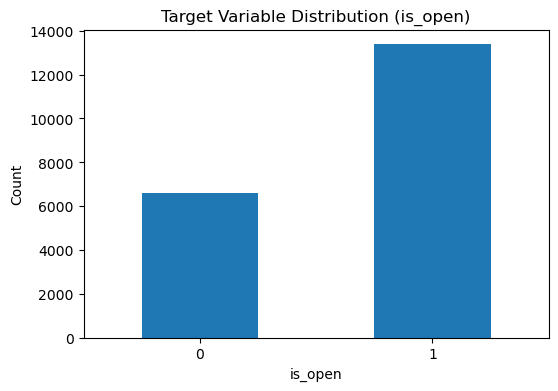

In [68]:
print("Target Variable Distribution:")
print(df['is_open'].value_counts())
print(df['is_open'].value_counts(normalize=True))

plt.figure(figsize=(6,4))
df['is_open'].value_counts().sort_index().plot(kind='bar')
plt.title("Target Variable Distribution (is_open)")
plt.xlabel("is_open")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


3.5.2 Univariate Analysis

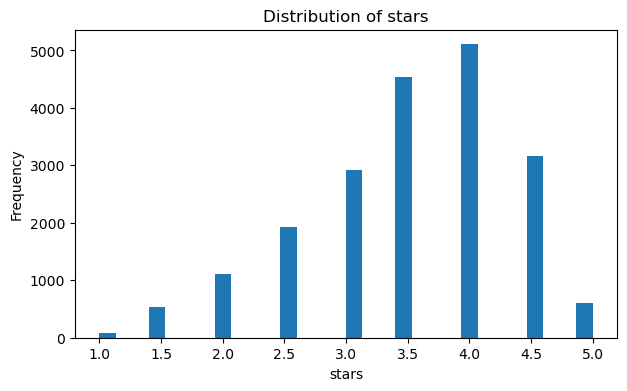

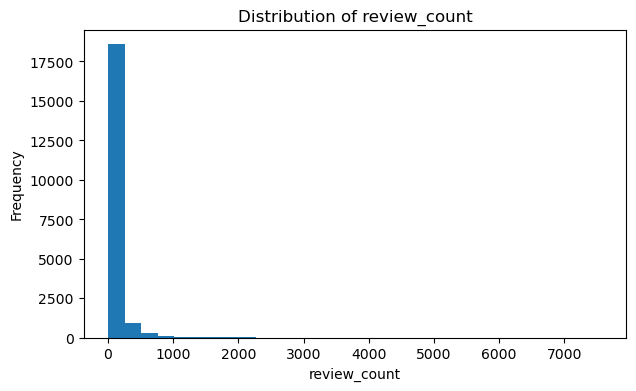

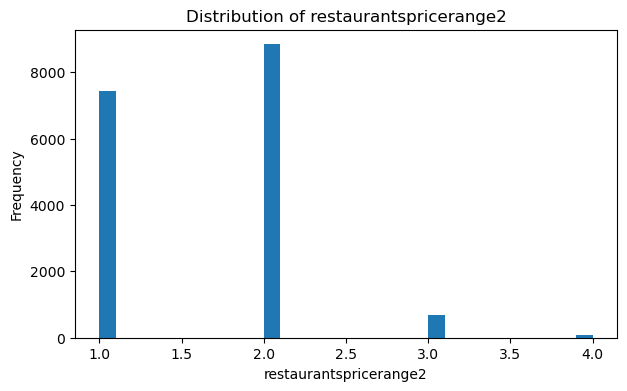

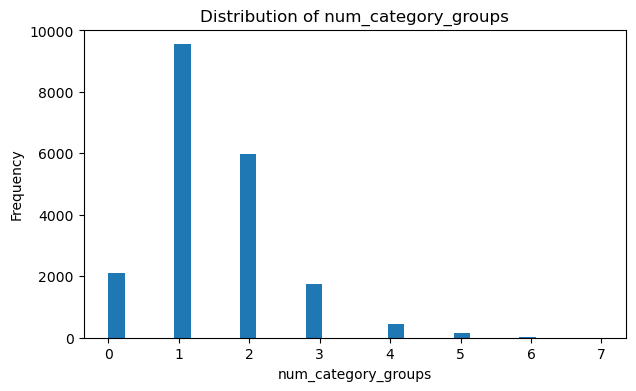

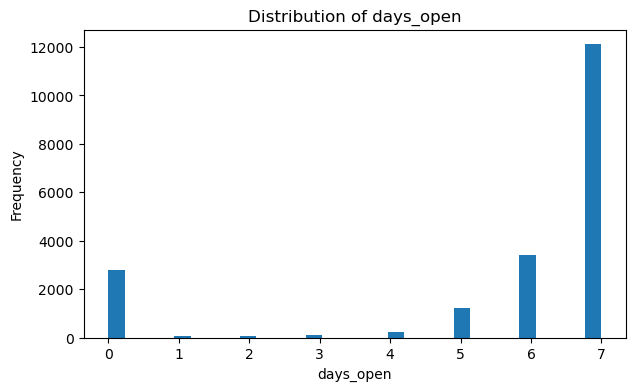


Univariate Summary:
             stars  review_count  restaurantspricerange2  num_category_groups  \
count  20000.00000  20000.000000            17030.000000         20000.000000   
mean       3.51500     86.880300                1.611509             1.470500   
std        0.82655    198.276202                0.586704             0.938336   
min        1.00000      5.000000                1.000000             0.000000   
25%        3.00000     13.000000                1.000000             1.000000   
50%        3.50000     33.000000                2.000000             1.000000   
75%        4.00000     88.000000                2.000000             2.000000   
max        5.00000   7568.000000                4.000000             7.000000   

          days_open  
count  20000.000000  
mean       5.638950  
std        2.407132  
min        0.000000  
25%        6.000000  
50%        7.000000  
75%        7.000000  
max        7.000000  


In [69]:
numeric_features = ['stars', 'review_count', 'restaurantspricerange2', 'num_category_groups', 'days_open']
for col in numeric_features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    
for col in numeric_features:
    plt.figure(figsize=(7,4))
    df[col].plot(kind='hist', bins=30)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

print("\nUnivariate Summary:")
print(df[numeric_features].describe())

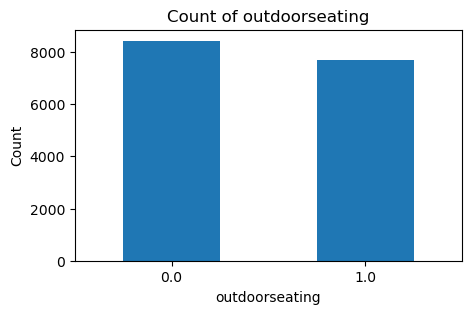

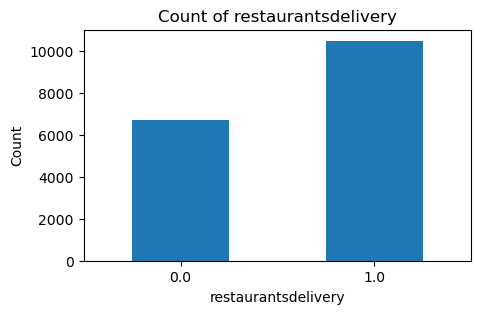

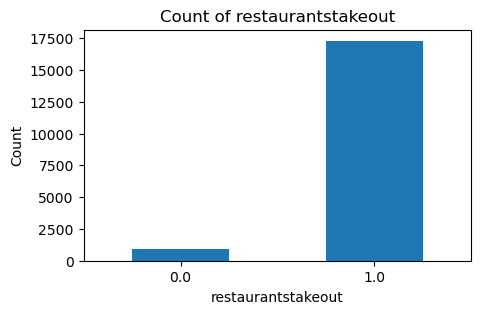

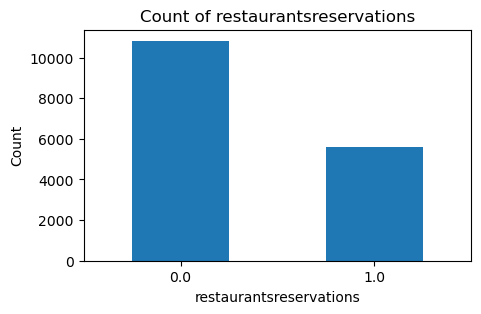

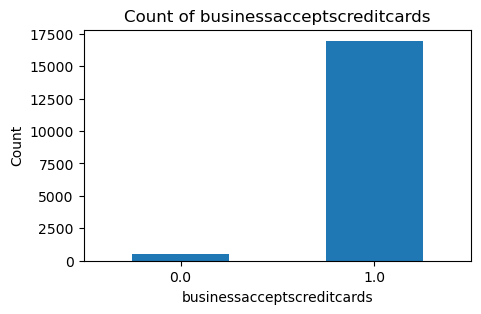

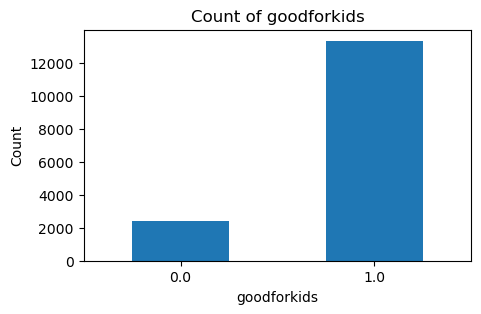

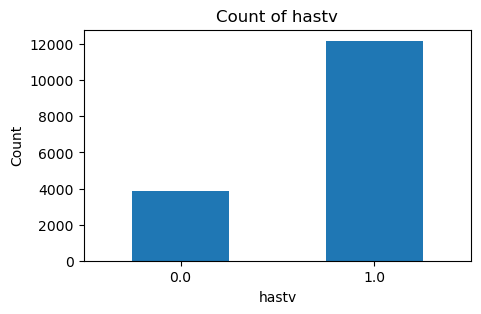

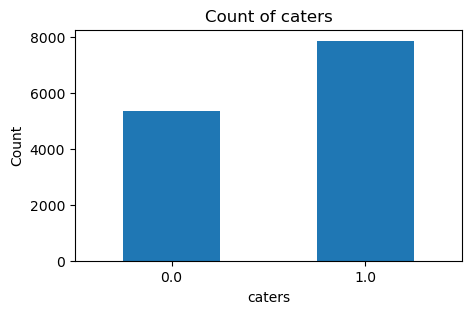

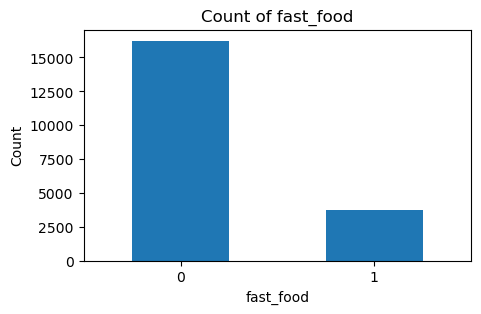

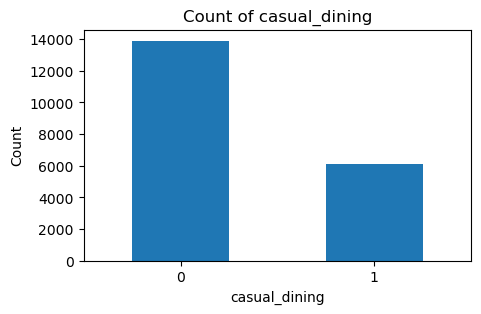

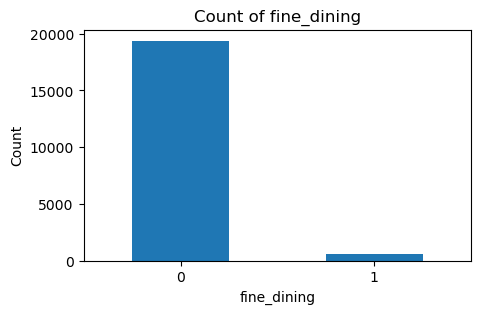

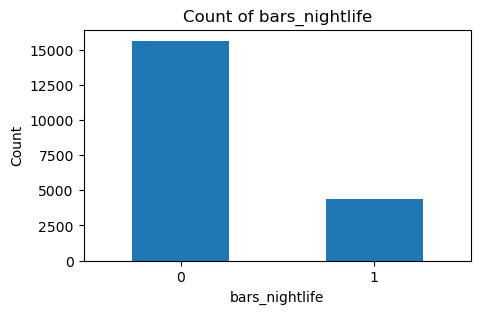

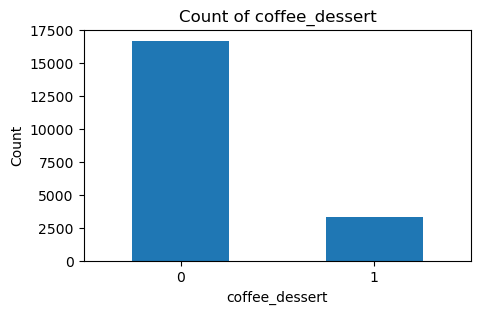

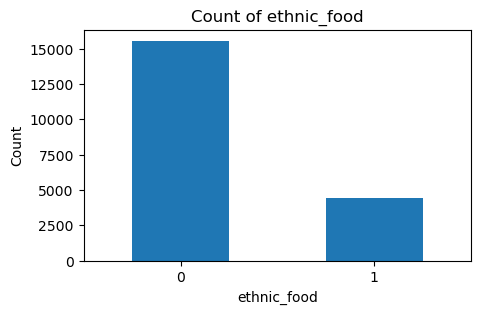

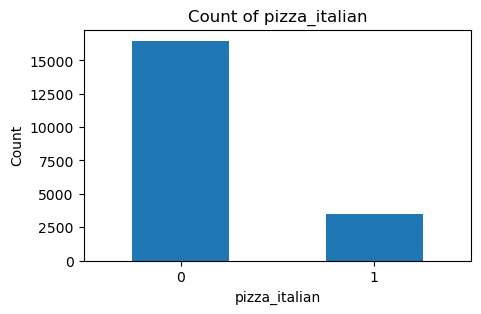

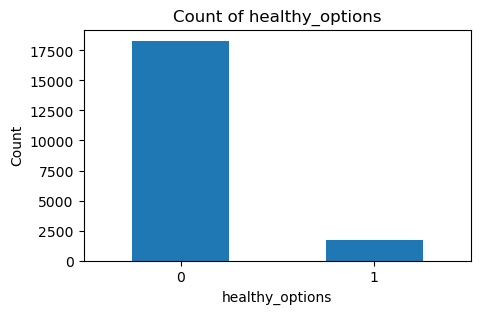

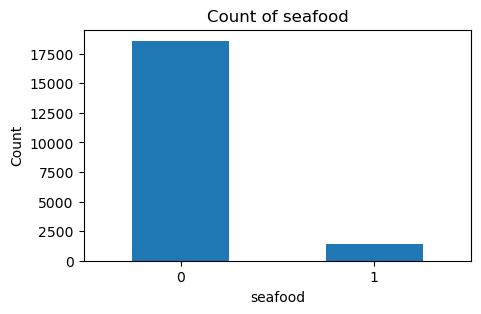

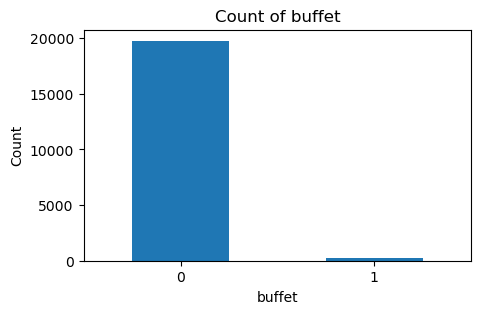

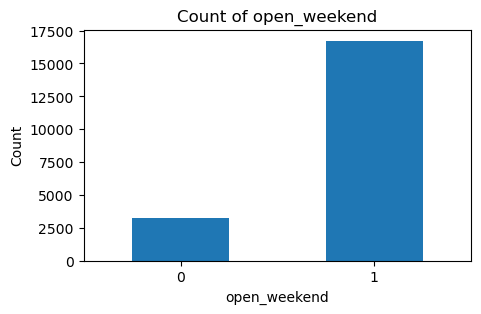

In [70]:
binary_features = [
    'outdoorseating', 'restaurantsdelivery', 'restaurantstakeout',
    'restaurantsreservations', 'businessacceptscreditcards',
    'goodforkids', 'hastv', 'caters',
    'fast_food', 'casual_dining', 'fine_dining', 'bars_nightlife',
    'coffee_dessert', 'ethnic_food', 'pizza_italian',
    'healthy_options', 'seafood', 'buffet', 'open_weekend'
]

for col in binary_features:
    plt.figure(figsize=(5,3))
    df[col].value_counts().sort_index().plot(kind='bar')
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

3.5.3 Bivariate Analysis

<Figure size 600x400 with 0 Axes>

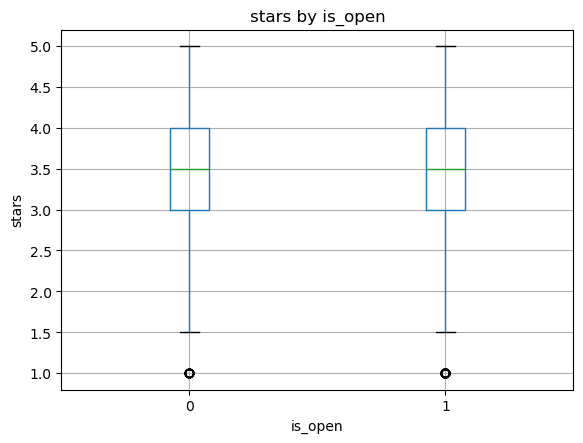

<Figure size 600x400 with 0 Axes>

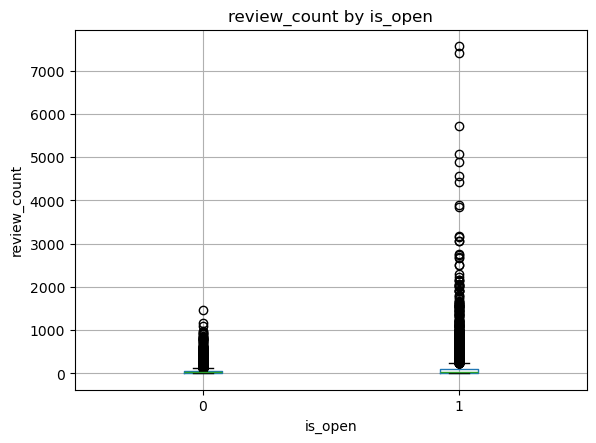

<Figure size 600x400 with 0 Axes>

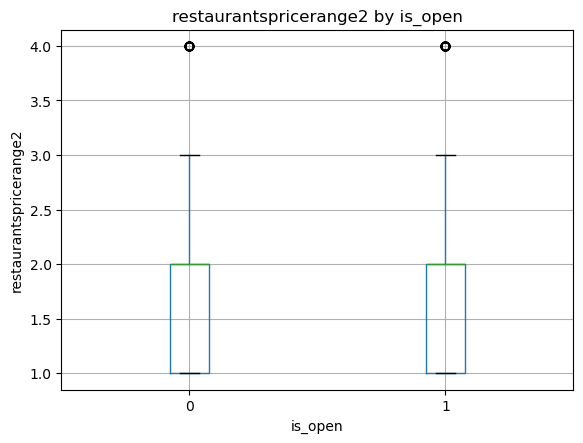

<Figure size 600x400 with 0 Axes>

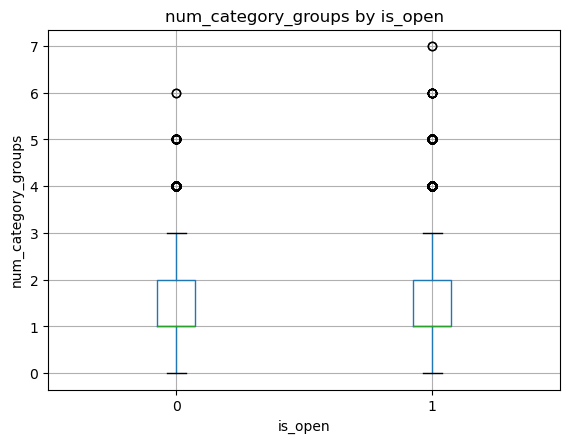

<Figure size 600x400 with 0 Axes>

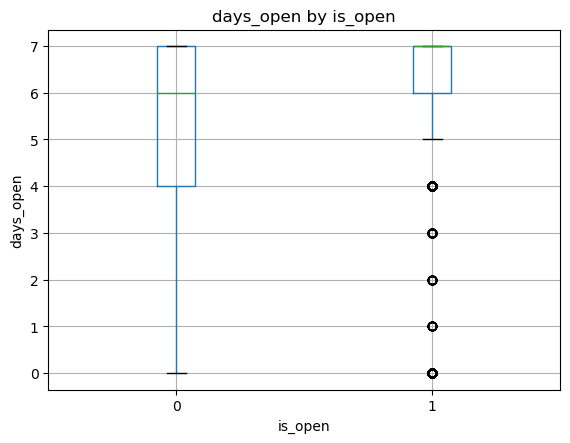

In [71]:
for col in numeric_features:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col, by='is_open')
    plt.title(f"{col} by is_open")
    plt.suptitle("")
    plt.xlabel("is_open")
    plt.ylabel(col)
    plt.show()

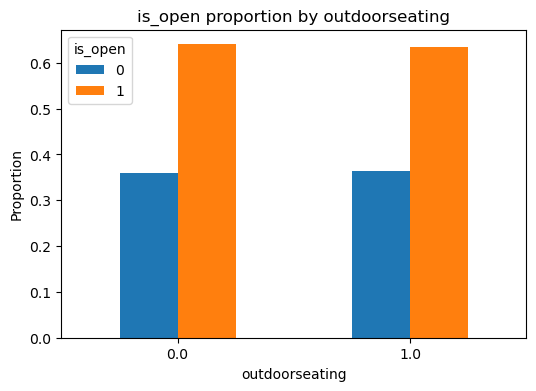

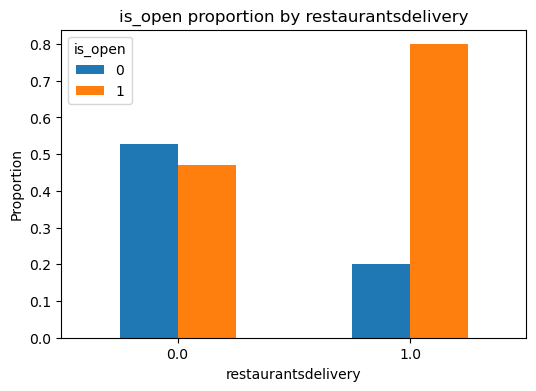

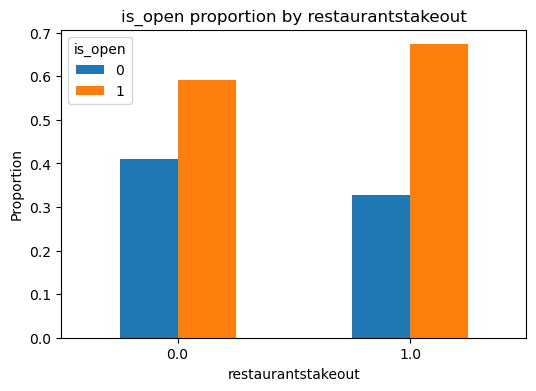

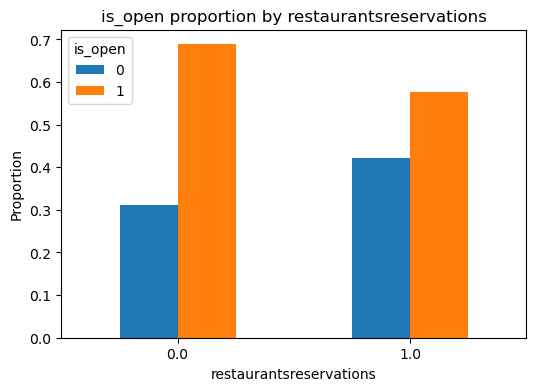

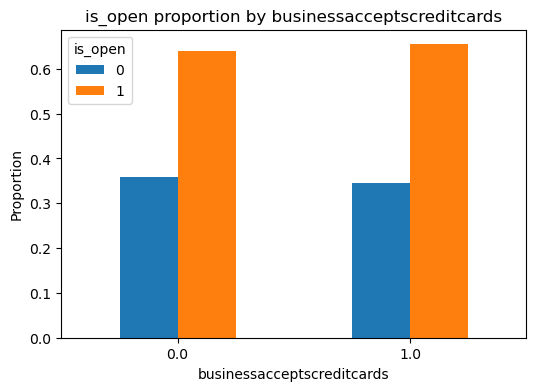

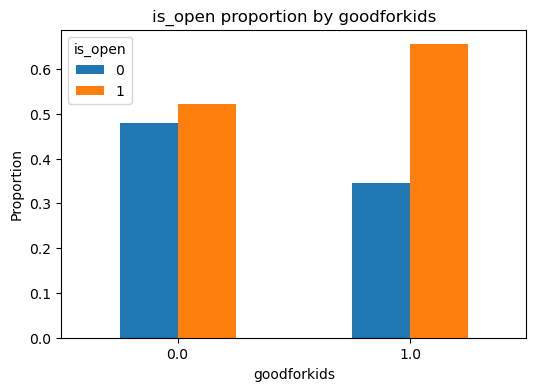

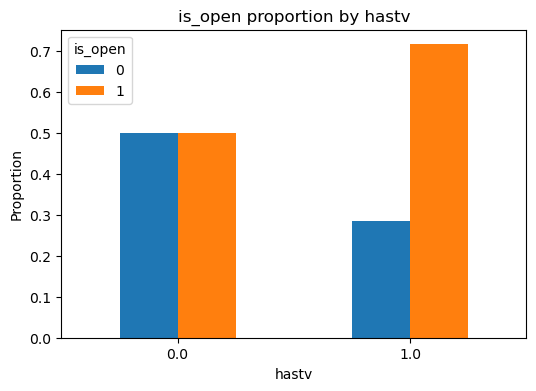

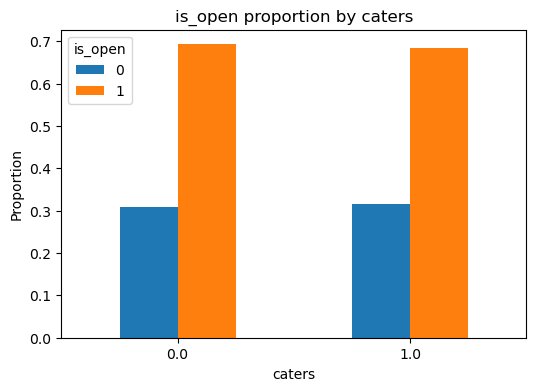

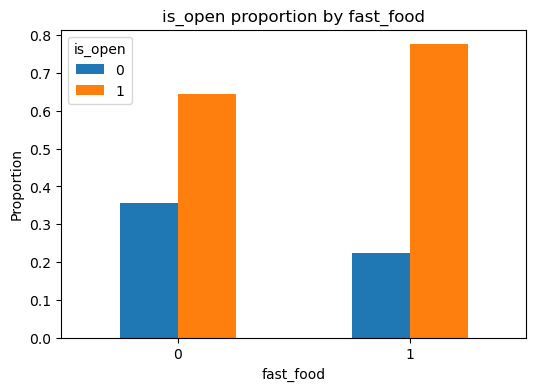

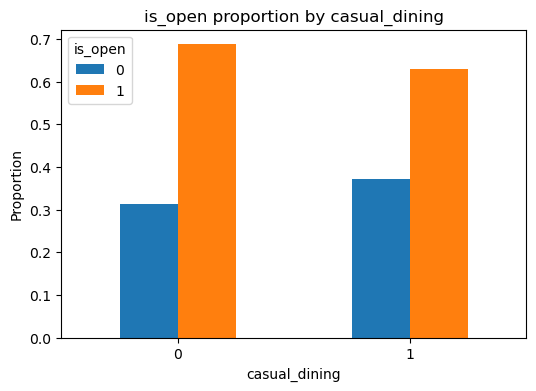

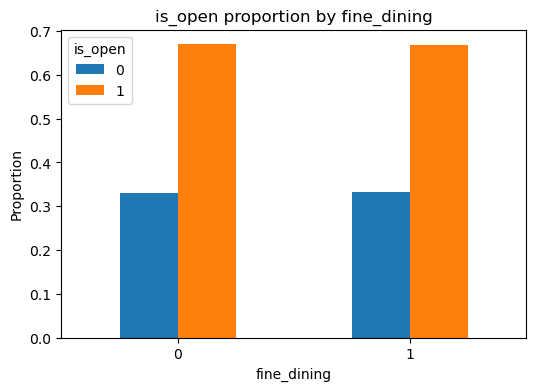

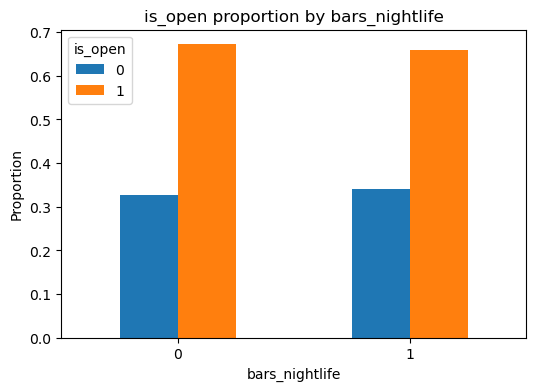

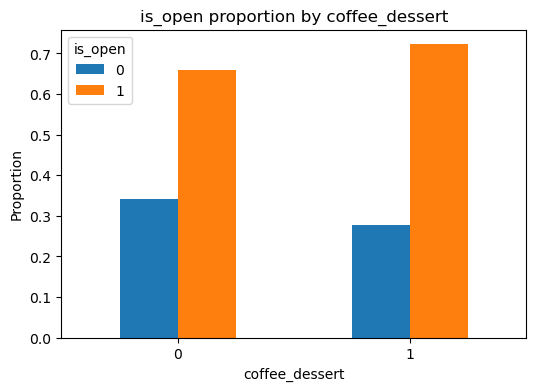

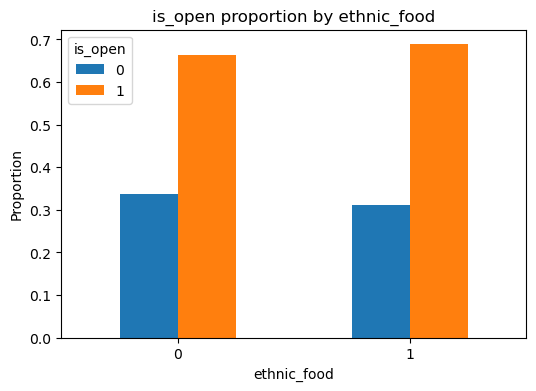

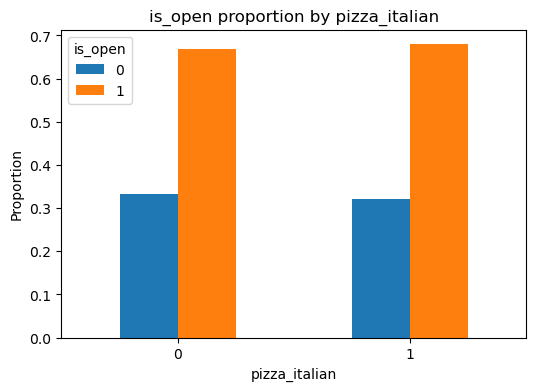

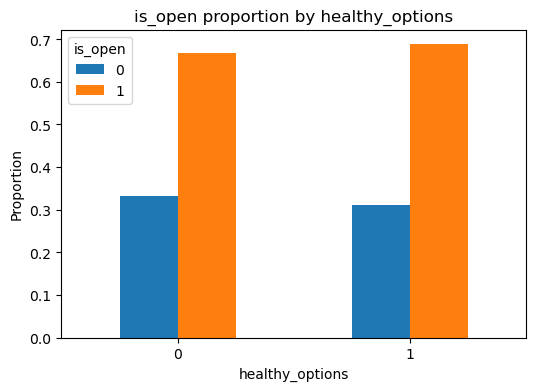

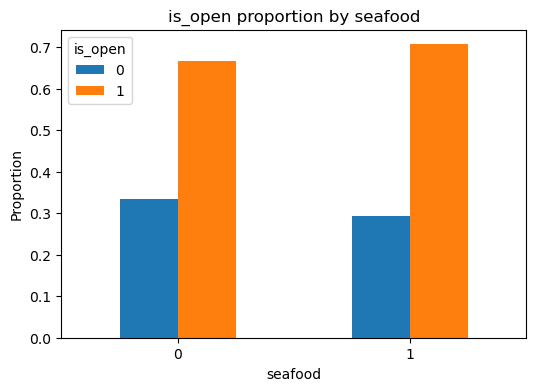

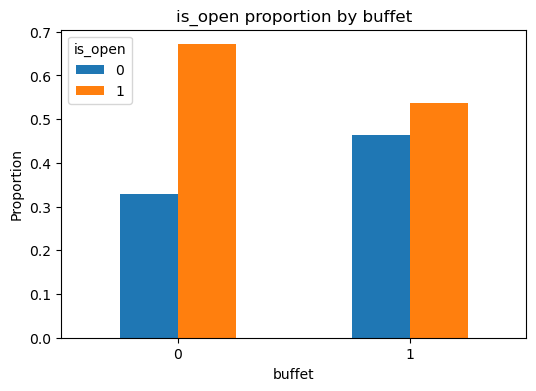

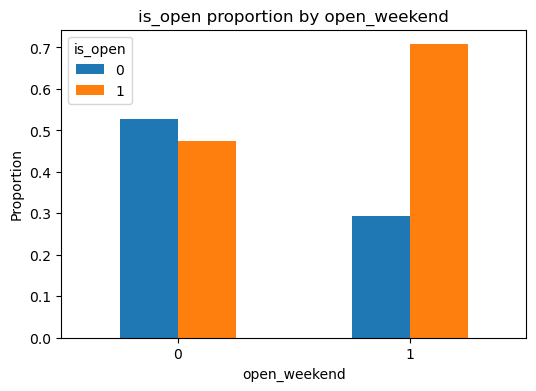

In [72]:
for col in binary_features:
    temp = pd.crosstab(df[col], df['is_open'], normalize='index')
    temp.plot(kind='bar', figsize=(6,4))
    plt.title(f"is_open proportion by {col}")
    plt.xlabel(col)
    plt.ylabel("Proportion")
    plt.xticks(rotation=0)
    plt.legend(title='is_open')
    plt.show()

In [73]:
print("\nMean Numeric Features by Target:")
print(df.groupby('is_open')[numeric_features].mean())


Mean Numeric Features by Target:
            stars  review_count  restaurantspricerange2  num_category_groups  \
is_open                                                                        
0        3.491907     52.632128                1.686917             1.401755   
1        3.526402    103.790798                1.570405             1.504444   

         days_open  
is_open             
0         4.946302  
1         5.980955  


3.5.4 Mulivariate Analysis


Correlation with Target:
is_open                       1.000000
restaurantsdelivery           0.340554
days_open                     0.202201
hastv                         0.194865
open_weekend                  0.183776
review_count                  0.121377
fast_food                     0.108738
goodforkids                   0.099743
num_category_groups           0.051482
coffee_dessert                0.050399
restaurantstakeout            0.038311
ethnic_food                   0.021738
seafood                       0.021461
latitude                      0.020760
stars                         0.019632
healthy_options               0.012126
pizza_italian                 0.009827
businessacceptscreditcards    0.004802
fine_dining                  -0.000834
outdoorseating               -0.005514
caters                       -0.008367
longitude                    -0.008445
bars_nightlife               -0.011017
buffet                       -0.030483
casual_dining                -0.057706

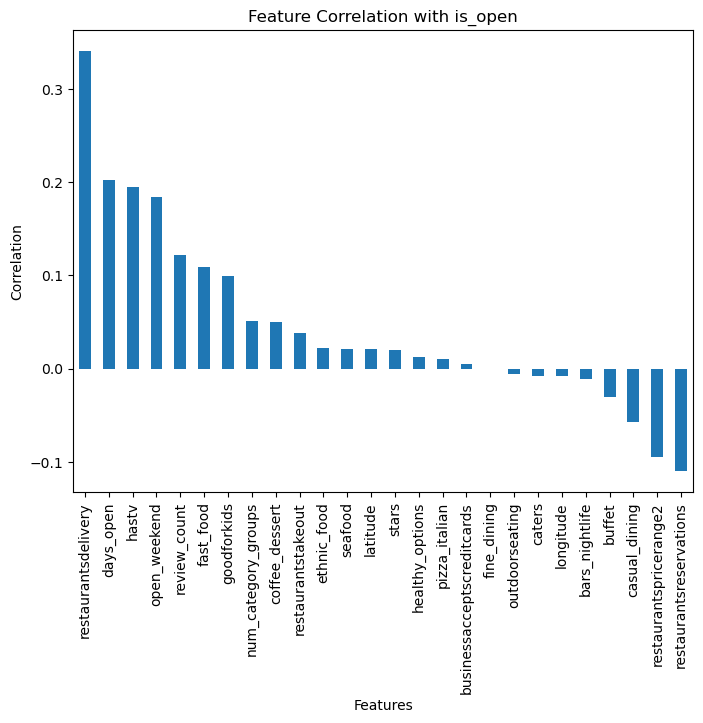

In [74]:
corr_with_target = df.corr(numeric_only=True)['is_open'].sort_values(ascending=False)
print("\nCorrelation with Target:")
print(corr_with_target)

plt.figure(figsize=(8,6))
corr_with_target.drop('is_open').plot(kind='bar')
plt.title("Feature Correlation with is_open")
plt.xlabel("Features")
plt.ylabel("Correlation")
plt.xticks(rotation=90)
plt.show()

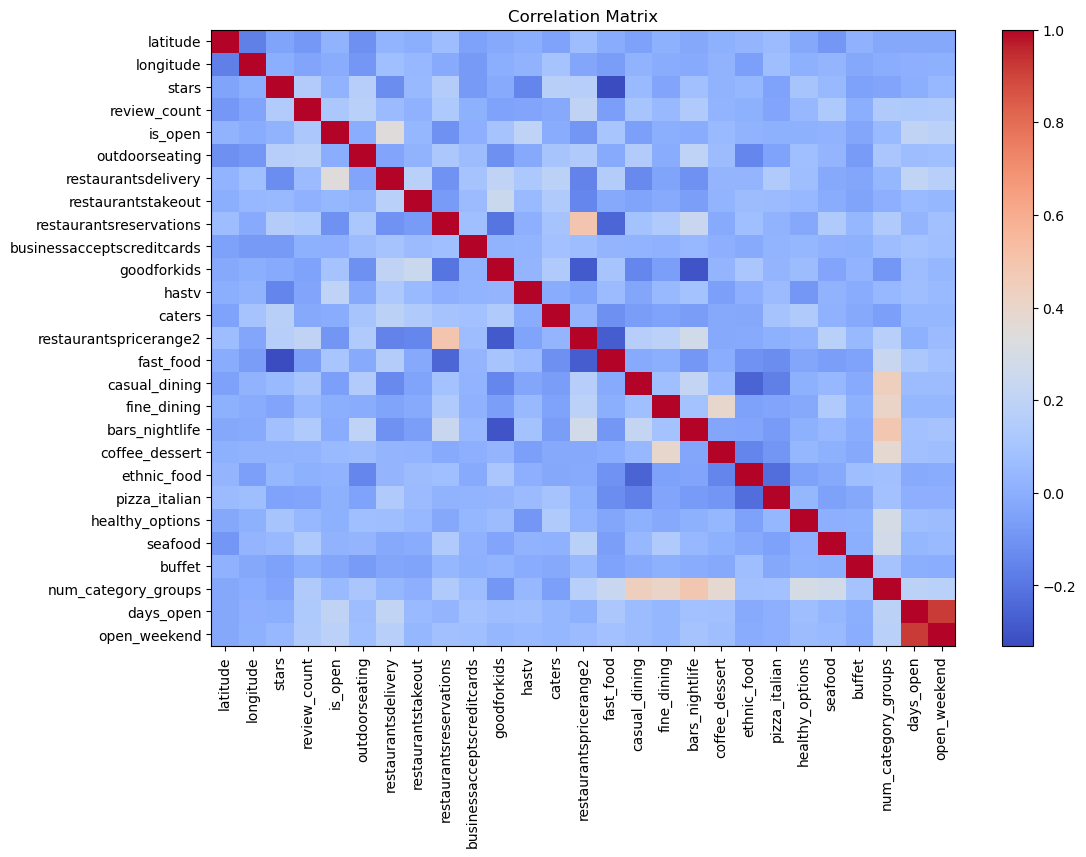

In [75]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(12,8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix.columns)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix.columns)), corr_matrix.columns)
plt.title("Correlation Matrix")
plt.show()

3.3.5 Selected Features

In [78]:
X = X.select_dtypes(include=[np.number])

low_variance_cols = [col for col in X.columns if X[col].nunique() <= 1]
X = X.drop(columns=low_variance_cols)

print("\nDropped low-variance columns:")
print(low_variance_cols)

feature_rank = X.corrwith(y).abs().sort_values(ascending=False)

print("\nFeature Ranking by Absolute Correlation with Target:")
print(feature_rank)

top_features = feature_rank.head(10).index.tolist()

print("\nTop 10 Selected Features:")
print(top_features)

X_selected = X[top_features].copy()

print("\nFinal Selected Feature Set Shape:")
print(X_selected.shape)

print("\nSelected Features Preview:")
print(X_selected.head())


Dropped low-variance columns:
[]

Feature Ranking by Absolute Correlation with Target:
restaurantsdelivery           0.340554
days_open                     0.202201
hastv                         0.194865
open_weekend                  0.183776
review_count                  0.121377
restaurantsreservations       0.109905
fast_food                     0.108738
goodforkids                   0.099743
restaurantspricerange2        0.094896
casual_dining                 0.057706
num_category_groups           0.051482
coffee_dessert                0.050399
restaurantstakeout            0.038311
buffet                        0.030483
ethnic_food                   0.021738
seafood                       0.021461
latitude                      0.020760
stars                         0.019632
healthy_options               0.012126
bars_nightlife                0.011017
pizza_italian                 0.009827
longitude                     0.008445
caters                        0.008367
outdoorseating 